#### Run this notebook in Juypter with the `conda qmcpy` environment or [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/MATH565Fall2025/blob/main/notebooks/GeneratingRandomVectors.ipynb?flush_cache=true)

In [1]:
if "google.colab" in str(get_ipython()):
    print("⚡Note: Setup here can take a few minutes.")
    !apt-get -y install cm-super dvipng texlive-latex-extra texlive-latex-recommended
    !pip install git+https://github.com/QMCSoftware/QMCSoftware.git@develop
    !git clone https://github.com/QMCSoftware/MATH565Fall2025.git
    %cd MATH565Fall2025/notebooks
    print("\n✅ Colab setup complete.")
    print("   For faster performance, please install the qmcpy environment locally.")

### Import needed packages and initialize some parameters

In [5]:
import sys, time
import numpy as np, scipy as sp, matplotlib.pyplot as plt
import qmcpy as qp
from pathlib import Path
from IPython.display import display, Markdown
REPO_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(REPO_ROOT))
from classlib.discrepancy import (mmd, mmd_prefix_against_measure, make_kernel, make_cd_kernel, restrict_to_unit_cube,
    AnalyticalMeasure, CDUniformMeasure, cd_uniform_k_mean, cd_uniform_k_self, show_mmd_usage)
import nbviz as nb
nb.init(use_tex=True)     # styling, Tol cycle, CSS
colors, TINY = nb.TOL_BRIGHT, nb.TINY

## Discrepancy
$$
\begin{aligned}
D^2\bigl(F_{\boldsymbol{X}},F_{\boldsymbol{Z}},K\bigr)
& = \int_{\mathcal{X} \times \mathcal{X}} K(\boldsymbol{x}, \boldsymbol{x}') \, \mathrm{d} F_{\boldsymbol{X}}(\boldsymbol{x})
\mathrm{d} F_{\boldsymbol{X}}(\boldsymbol{x}')
- 2 \int_{\mathcal{X} \times \mathcal{X}} K(\boldsymbol{x}, \boldsymbol{z}) \, \mathrm{d} F_{\boldsymbol{X}}(\boldsymbol{x})
\mathrm{d} F_{\boldsymbol{Z}}(\boldsymbol{z}) \\
& \qquad \qquad + \int_{\mathcal{X} \times \mathcal{X}}
K(\boldsymbol{z}, \boldsymbol{z}') \, \mathrm{d} F_{\boldsymbol{Z}}(\boldsymbol{z})
\mathrm{d} F_{\boldsymbol{Z}}(\boldsymbol{z}') \\
& =  \int_{\mathcal{X} \times \mathcal{X}} K(\boldsymbol{x}, \boldsymbol{x}') \, \mathrm{d} [F_{\boldsymbol{X}}(\boldsymbol{x}) - F_{\boldsymbol{Z}}(\boldsymbol{x})
\mathrm{d} [F_{\boldsymbol{X}}(\boldsymbol{x}')  - F_{\boldsymbol{Z}}(\boldsymbol{x}')] \\
& = \int_{\mathcal{X} \times \mathcal{X}} K(\boldsymbol{x}, \boldsymbol{x}') \, \varrho_{\boldsymbol{X}}(\boldsymbol{x})
\varrho_{\boldsymbol{X}}(\boldsymbol{x}') \, \mathrm{d} \boldsymbol{x} \mathrm{d} \boldsymbol{x}'
- 2 \int_{\mathcal{X} \times \mathcal{X}} K(\boldsymbol{x}, \boldsymbol{z}) \, \varrho_{\boldsymbol{X}}(\boldsymbol{x}) \varrho_{\boldsymbol{Z}}(\boldsymbol{z}) \,\mathrm{d}\boldsymbol{x} \mathrm{d}\boldsymbol{z}\\
& \qquad \qquad + \int_{\mathcal{X} \times \mathcal{X}} K(\boldsymbol{z}, \boldsymbol{z}') \, \varrho_{\boldsymbol{Z}}(\boldsymbol{z})
\varrho_{\boldsymbol{Z}}(\boldsymbol{z}') 
 \,\mathrm{d}\boldsymbol{z} \mathrm{d}\boldsymbol{z}' \ge 0
\end{aligned}
$$

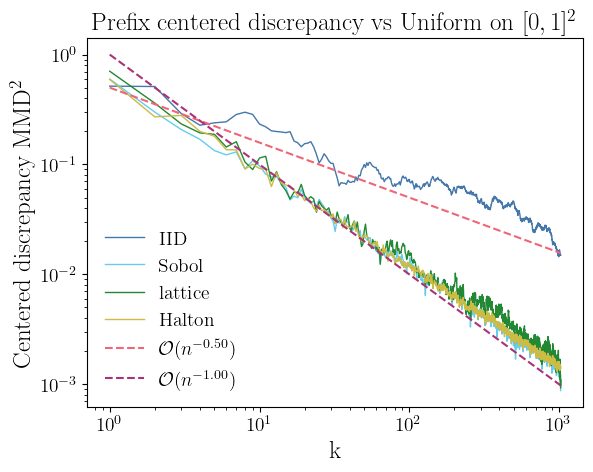

In [25]:
# ---- config ----
d      = 2
n_max  = 2**10
gamma  = 1.0
ks = np.arange(1, n_max+1)

# ---- kernel + measure ----
kernel  = make_cd_kernel(d, gamma)
measure = CDUniformMeasure(d, gamma)

# ---- generators ----
def prefix_mmd2_for(gen_pts, n, d, kernel, measure):
    X = gen_pts(n, d)
    return mmd_prefix_against_measure(X, kernel, measure, return_sqrt=True)

gens = {
    "IID":     lambda n,d: np.random.default_rng(0).random((n,d)),
    "Sobol":   lambda n,d: qp.Sobol(dimension=d).gen_samples(n),
    "lattice": lambda n,d: qp.Lattice(dimension=d).gen_samples(n),
    "Halton":  lambda n,d: qp.Halton(dimension=d).gen_samples(n),
    
}

# ---- plot ----
fig, ax = plt.subplots()
for name, gen in gens.items():
    m2 = prefix_mmd2_for(gen, n_max, d, kernel, measure)
    ax.loglog(ks, m2, label=name, lw=1)
nb.plot_power_line(coef=0.5, power=-0.5, x=(ks[0],ks[-1]), ax=ax)
nb.plot_power_line(coef=1, power=-1, x=(ks[0],ks[-1]), ax=ax)
    
plt.xlabel("k")
plt.ylabel("Centered discrepancy MMD$^2$")
plt.title(rf"Prefix centered discrepancy vs Uniform on $[0,1]^{{{d}}}$")
plt.legend(loc = "lower left")
#plt.grid(True, which="both", ls=":")
plt.show()